# Setup

In [1]:
# main
import re
import numpy as np
import pandas as pd
import scipy.stats as stats
# import xarray as xr
# from patsy import dmatrix

# preprocessing
from sklearn.base import BaseEstimator, TransformerMixin
# from sklearn.preprocessing import MaxAbsScaler
from statsmodels.tsa.tsatools import add_trend

# modeling
import pytensor.tensor as pt
import pymc as pm
import pymc_bart as pmb
# import pymc.sampling_jax

# charts
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az

# util
from IPython.display import display

In [2]:
class StandardScalerDF:

    def __init__(self, mean=None, std=None):
        self.mean_ = mean
        self.std_ = std

    def fit(self, X):
        self.mean_ = X.mean()
        self.std_ = X.std()
        return self

    def transform(self, X):
        if self.mean_ is None or self.std_ is None:
            raise ValueError("Scaler has not been fit yet.")
        scaled_X = (X - self.mean_) / self.std_
        return scaled_X

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

    def inverse_transform(self, X_scaled):
        if self.mean_ is None or self.std_ is None:
            raise ValueError("Scaler has not been fit yet.")
        X = X_scaled * self.std_ + self.mean_
        return X

In [3]:
# Custom transformer to scale and return DataFrame
class MinMaxScalerDF(BaseEstimator, TransformerMixin):

    def __init__(self, feature_range=(0, 1)):
        self.feature_range = feature_range

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        min_new, max_new = self.feature_range
        X_std = (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0))
        scaled_data = X_std * (max_new - min_new) + min_new
        return scaled_data

In [4]:
# Calculate the two-tailed p-value
def p_value_2_tail(pdr):
    p_value = 2 * np.min([
        np.mean(pdr <= 0),  # Proportion of draws <= 0
        np.mean(pdr > 0)   # Proportion of draws > 0
    ])
    return p_value

In [5]:
def prsquared(q, endog, resid):
    e = resid
    e = np.where(e < 0, (1 - q) * e, q * e)
    e = np.abs(e)
    ered = endog - stats.scoreatpercentile(endog, q * 100)
    ered = np.where(ered < 0, (1 - q) * ered, q * ered)
    ered = np.abs(ered)
    return 1 - np.sum(e) / np.sum(ered)

In [6]:
def bqr_results(trace, var_names, q_pred_name="μ"):
    bqcoef_col_names = {
        'mean': 'coeff', 'sd': 'se',
        'hdi_2.5%': 'lower', 'hdi_97.5%': 'upper'
    }
    stats_funcs = {
        'pval': p_value_2_tail
    }

    # indices, predictions and target
    date_index = pd.DatetimeIndex(trace.observed_data['date'], name='date')
    quantiles_index = pd.Series(trace.observed_data['quantiles'], name='quantile')
    y_pred = trace.posterior[q_pred_name].mean(("chain", "draw"))
    y_true = pd.Series(trace.observed_data['obs'][:, 1], index=date_index, name='actual')

    # extract coeffs
    bqcoef = az.summary(trace, var_names=var_names, hdi_prob=0.95, stat_funcs=stats_funcs, extend=True, kind="all")
    bqcoef = bqcoef.rename(columns=bqcoef_col_names).drop(columns=['mcse_mean', 'mcse_sd'])
    bqcoef_index = bqcoef.index.str.extract(r'^(.*?)(?:\[(?:([\w\s]+)?,?\s?(\d+\.\d+)?)?\])?$')
    bqcoef_index[0] = bqcoef_index[0]+bqcoef_index[1].apply(lambda x: f"_{x}" if pd.notna(x) else '')
    bqcoef_index = bqcoef_index.drop(columns=1).rename(columns={0: 'variable', 2: 'quantile'})
    bqcoef_index['quantile'] = bqcoef_index['quantile'].astype(float).fillna(0)
    bqcoef_index = pd.MultiIndex.from_frame(bqcoef_index)
    bqcoef = bqcoef.set_index(bqcoef_index)

    # extract predictions
    bqr_pred = pd.DataFrame(y_pred, columns=quantiles_index, index=date_index)
    bqr_pred = bqr_pred.stack().rename('conditional_mean')
    bqr_pred = pd.merge(bqr_pred, y_true, 'left', on='date').set_index(bqr_pred.index)
    bqr_pred['residual'] = bqr_pred['actual'] - bqr_pred['conditional_mean']

    # adding pseudo-r2 to coeffs
    pr2 = bqr_pred.groupby('quantile').apply(lambda x: prsquared(x.index[0][1], x['actual'], x['residual'])).rename('pseudoR2')
    bqcoef = pd.merge(bqcoef, pr2, 'left', on='quantile').set_index(bqcoef.index)

    # returning coeffs and predictions
    return bqcoef, bqr_pred

In [7]:
def summary_with_stars(bqcoef, q=[0.1, 0.5], prefix="GDP growth, "):
    """
    Generate a summary table with coefficients, standard errors, significance stars, and R2 for multiple models,
    displaying coefficients and standard errors on separate rows, with one column per model.

    Parameters:
    - bqcoef: Dataframe of models with "coeff", "se", "pval", "variable_name", and "R2" as columns.
    - q: A list of quantiles to for which to report summary statistics.

    Returns:
    - A pandas DataFrame with the summary table and significance stars.
    """

    # Define star levels based on p-values
    def significance_stars(pval):
        if pval <= 0.01:
            return '***'
        elif pval <= 0.05:
            return '**'
        elif pval <= 0.1:
            return '*'
        else:
            return ''

    # Create a list of rows with coefficients and standard errors for each model
    result_list = []

    # Create models dict
    model_info = bqcoef.reset_index('variable').groupby(['expectation', 'horizon', 'quantile'])
    model_info = model_info.apply(lambda x: x.to_dict('list'))
    target_models = model_info.index.get_level_values('quantile').isin(q)
    model_info = model_info[target_models].copy()
    model_info_names = model_info.index.to_frame().apply(lambda x: f"q={x['quantile']}, h={x['horizon']}, e={x['expectation']}", axis=1)
    model_info.index = model_info_names.values
    models = model_info.to_dict()

    # Assume all models have the same variable names (based on the first model)
    variable_names = models[next(iter(models))]["variable"]

    # Prepare the result for each model
    for i, var_name in enumerate(variable_names):
        row_coeff = {'variable': var_name}
        row_se = {
            'variable': ""
        }  # SE row will have an empty string for variable name

        for model_name, model_data in models.items():
            pmodel_name = f"{prefix}{model_name}"
            coeff = model_data["coeff"][i]
            se = model_data["se"][i]
            pval = model_data["pval"][i]

            # Coefficients and significance stars
            coeff_str = f'{coeff:.3f}{significance_stars(pval)}'
            se_str = f'({se:.1f})'

            # Add to row for each model
            row_coeff[pmodel_name] = coeff_str
            row_se[pmodel_name] = se_str

        result_list.append(row_coeff)
        result_list.append(row_se)

    # Add R2 row at the end of the table
    row_r2 = {'variable': 'Pseudo-R2'}
    for model_name, model_data in models.items():
        pmodel_name = f"{prefix}{model_name}"
        r2 = model_data["pseudoR2"][0]
        row_r2[pmodel_name] = f'{r2:.3f}'

    result_list.append(row_r2)

    # Create the final result DataFrame
    result = pd.DataFrame(result_list).set_index('variable')
    return result

In [8]:
def plot_qr_coeff(qcoef_table, variable, expectation='forward', horizon=4, ax=None):
    variable_coeffs = qcoef_table.loc[expectation].loc[horizon].loc[variable].copy()
    variable_coeffs = variable_coeffs.rename(columns={'coeff_scale': variable, 'coeff': variable})
    variable_coeffs.index = variable_coeffs.index.astype(float)
    ax = variable_coeffs.plot(y=variable, title=f"{variable} horizon={horizon}, e={expectation}", ax=ax)
    ax.fill_between('quantile', 'lower', 'upper', data=variable_coeffs.reset_index(),
                    color='k', alpha=.1)
    ax.axhline(0, alpha=0.5)
    return ax

In [9]:
RANDOM_SEED = 5781
np.random.seed(RANDOM_SEED)
az.style.use("arviz-darkgrid")
sns.reset_defaults()

# Estimation: bmi and age

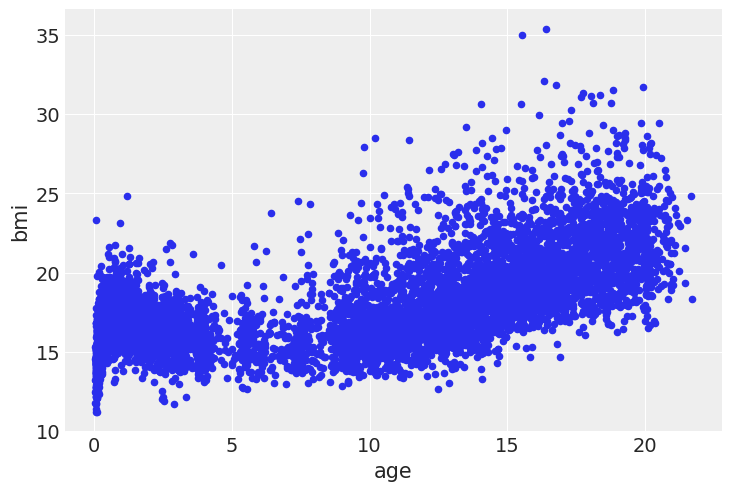

In [5]:
# loading data
bmi = pd.read_csv(pm.get_data("bmi.csv"))
bmi.plot(x="age", y="bmi", kind="scatter")
plt.show()

In [6]:
y = bmi.bmi.values
X = bmi.age.values[:, None]
y_stack = np.stack([y] * 3)
quantiles = np.array([[0.1, 0.5, 0.9]]).T

print('y shape:', y.shape)
print('X shape:', X.shape)
print('y_stack shape:', y_stack.shape)
print('quantiles:\n', quantiles)

y shape: (7294,)
X shape: (7294, 1)
y_stack shape: (3, 7294)
quantiles:
 [[0.1]
 [0.5]
 [0.9]]


In [7]:
with pm.Model() as model:
    μ = pmb.BART("μ", X, y, shape=(3, 7294))
    σ = pm.HalfNormal("σ", 5)
    obs = pm.AsymmetricLaplace("obs", mu=μ, b=σ, q=quantiles, observed=y_stack)
    idata = pm.sample(compute_convergence_checks=False)

/Users/victoryerz/anaconda3/lib/python3.11/site-packages/pytensor/tensor/math.py:893: FutureWarning: sgn is deprecated and will stop working in the future, use sign instead.
  warnings.warn(
/Users/victoryerz/anaconda3/lib/python3.11/site-packages/pytensor/tensor/math.py:893: FutureWarning: sgn is deprecated and will stop working in the future, use sign instead.
  warnings.warn(
/Users/victoryerz/anaconda3/lib/python3.11/site-packages/pytensor/tensor/math.py:893: FutureWarning: sgn is deprecated and will stop working in the future, use sign instead.
  warnings.warn(
/Users/victoryerz/anaconda3/lib/python3.11/site-packages/pytensor/tensor/math.py:893: FutureWarning: sgn is deprecated and will stop working in the future, use sign instead.
  warnings.warn(
/Users/victoryerz/anaconda3/lib/python3.11/site-packages/pytensor/tensor/math.py:893: FutureWarning: sgn is deprecated and will stop working in the future, use sign instead.
  warnings.warn(
/Users/victoryerz/anaconda3/lib/python3.11/si

Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 204 seconds.


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

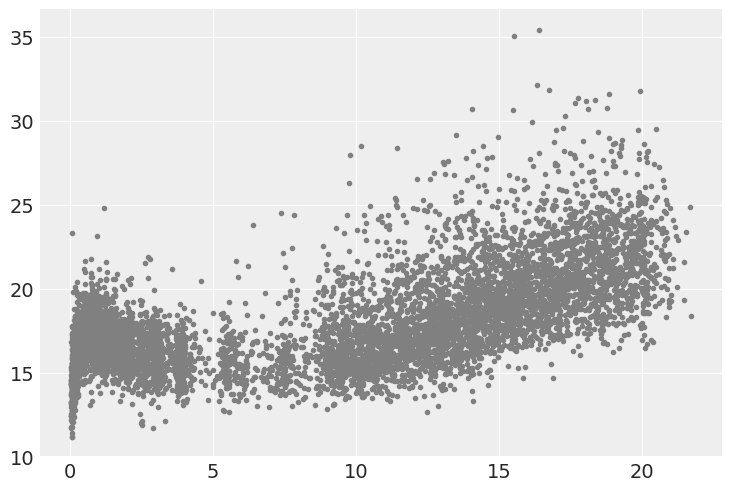

In [56]:
plt.plot(bmi.age, bmi.bmi, ".", color="0.5")
for idx, q in enumerate(quantiles[:, 0]):
    plt.plot(
        bmi.age,
        idata.posterior["μ"].mean(("chain", "draw")).sel(μ_dim_0=idx),
        label=f"q={q:}",
        lw=3,
    )
plt.legend()
plt.show()

# Estimation: GDP growth in Armenia

## setup

In [10]:
# loading data
X_selected = pd.read_pickle('../../data/working_data/arm_X_selected.pkl')
Y = pd.read_pickle('../../data/working_data/arm_Y.pkl')
Ar = pd.read_pickle('../../data/working_data/arm_Ar.pkl')
Arr = pd.read_pickle('../../data/working_data/arm_Arr.pkl')

In [11]:
# dimension setup
mm = MinMaxScalerDF()
horizons = list(range(4, 12+1, 4))
quantiles = np.arange(0.05, 0.95, 0.05).round(2)
model_select_cols = [
    'const',
    # 'Credit GDP ratio', 'Credit GDP gap',
    'Financial Cycle Index',
    # 'Short-term GB rate', 'Mid-term GB rate',
    # 'Long-term GB rate', 'Level',
    # 'Steepness', 'Curvature', 'Bank RoE',
    'Financial Conditions Index',
    'Liquidity excess',
    # 'CAR excess_C_2y',
    # 'CAR excess',
    # 'MP',
    # 'MPI',
    'FCI x FCyI',
    # 'MPI x FCyI', 'MPI x FCI',
    # 'MPI x CAR',
    # 'Mortgage stock', 'Mortgage flow',
    # 'Mortgage interest rate', 'Construction loans',
    # 'Real estate prices', 'Real house price',
    # 'DSTI',
    # 'Exchange rate', 'Trade balance', 'Copper prices',
    # 'CPI', 'Policy rate', 'Government debt',
    # 'Current account', 'Government expenditure',
    # 'Fiscal impulse QPM', 'Unemployment rate',
    'Macroeconomic Indicator'
]
# usable:
# Short-term GB rate
# DSTI

In [12]:
# exog variable setup
exog = X_selected.copy()
exog = add_trend(exog, trend='c')

# adding interaction effects
exog_mpi = exog['MPI'].copy()
exog_fcyi_norm = mm.fit_transform(exog['Financial Cycle Index']).rename('N(FCyI)')
exog_fci_norm = mm.fit_transform(exog['Financial Conditions Index']).rename('N(FCI)')
exog_car_excess = exog['CAR excess']
exog['FCI x FCyI'] = exog_fci_norm * exog_fcyi_norm
exog_interaction = pd.DataFrame(exog_mpi * exog_fcyi_norm, columns=['MPI x FCyI'])
exog_interaction['MPI x FCI'] = exog_mpi * exog_fci_norm
exog_interaction['MPI x CAR'] = exog_mpi * exog_car_excess
# adding real house prices using CPI
# exog['Real house price'] = exog['Real estate prices'] - np.log(exog['CPI'])
exog = exog[model_select_cols]
exog_full = pd.concat([exog, exog_car_excess, exog_fcyi_norm, exog_fci_norm, exog_mpi, exog_interaction], axis=1)

In [13]:
# dataset setup
macro_dataset = []
horizon_namer = re.compile(r'_([\d\.]+)y')

# for forward expectations
for index, y_name in enumerate(Y):
    horizon_years = horizon_namer.search(y_name).group(1)
    horizon = float(horizon_years) * 4
    endog = Y[y_name].copy()
    ar = Ar.iloc[:, index].copy()
    endog_new_name = horizon_namer.sub('', ar.name)
    macro_data = pd.concat([ar.rename('autoregressive'), exog_full], axis=1)
    macro_data = pd.concat([endog.rename(endog_new_name), macro_data], axis=1)
    macro_data['horizon'] = horizon

    # remove extra rows
    cutoff_date = macro_data.isna().groupby('date').sum().sum(axis=1).idxmin()
    macro_data = macro_data[macro_data.index.get_level_values('date') >= cutoff_date].copy()

    # add to the dataset
    macro_dataset.append(macro_data)

macro_dataset = pd.concat(macro_dataset).reset_index().set_index(['horizon', 'date']).sort_index()

In [14]:
# model specification
model_data = macro_dataset.loc[4].dropna().copy()
target_name = macro_data.columns[0]
y = model_data[target_name].copy()
y_stack = np.stack([y.values] * len(quantiles)).T
X_other = model_data[['autoregressive']+model_select_cols].copy()
X_fcyi_norm = model_data['N(FCyI)'].copy()
X_fci_norm = model_data['N(FCI)'].copy()
X_car_excess = model_data['CAR excess'].copy()
X_mpi = model_data['MPI'].copy()
X_interaction = model_data[exog_interaction.columns].copy()
X = pd.concat([X_other, X_mpi, X_interaction], axis=1)
date = y.index
X_variables = X.columns
X_other_variables = X_other.columns
X = X.values.copy()
X_other = X_other.values.copy()
poly_terms = np.array(["intercept", "slope", "quadratic", "cubic"])
gamma_terms = np.array(["intercept", "intercept_fcyi", "intercept_fci",
                        "slope", "quadratic", "cubic", "multiplier_car"])
coords = {"date": date, "variables": X_variables, "quantiles": quantiles, 'poly_terms': poly_terms}
coords_other = {"date": date, "variables": X_other_variables, "quantiles": quantiles,
                "poly_terms": poly_terms, "gamma_terms": gamma_terms}
quantile_powers = np.stack([quantiles**i for i in range(len(poly_terms))], axis=0)

## standard version

In [36]:
# model definition and fitting
with pm.Model(coords=coords) as bqr_model_standard:
    # data containers
    X_data = pm.Data(name="X_data", value=X, dims=("date", "variables"))

    # parameters
    β = pm.Normal("β", 0, 10, dims=("variables", "quantiles"))

    # estimation
    σ = pm.HalfNormal("σ", 10)
    μ = pm.Deterministic('μ', X_data @ β, dims=("date", "quantiles"))

    # likelihood function
    obs = pm.AsymmetricLaplace("obs", mu=μ, b=σ, q=quantiles, observed=y_stack, dims=("date", "quantiles"))

    # sampling
    trace_standard = pm.sample()

/Users/victoryerz/anaconda3/lib/python3.11/site-packages/pytensor/tensor/math.py:893: FutureWarning: sgn is deprecated and will stop working in the future, use sign instead.
  warnings.warn(
/Users/victoryerz/anaconda3/lib/python3.11/site-packages/pytensor/tensor/math.py:893: FutureWarning: sgn is deprecated and will stop working in the future, use sign instead.
  warnings.warn(
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
/Users/victoryerz/anaconda3/lib/python3.11/site-packages/pytensor/tensor/math.py:893: FutureWarning: sgn is deprecated and will stop working in the future, use sign instead.
  warnings.warn(
/Users/victoryerz/anaconda3/lib/python3.11/site-packages/pytensor/tensor/math.py:893: FutureWarning: sgn is deprecated and will stop working in the future, use sign instead.
  warnings.warn(
/Users/victoryerz/anaconda3/lib/python3.11/site-packages/pytensor/tensor/math.py:893: FutureWarning: sgn is deprecated and will stop working in the future, use 

Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 161 seconds.


## with linear coefficient relationships across quantiles

In [37]:
# model definition and fitting
with pm.Model(coords=coords) as bqr_model_linear:
    # data containers
    X_data = pm.Data(name="X_data", value=X, dims=("date", "variables"))

    # parameters
    β_c = pm.Normal("β_c", 0, 10, dims=("variables",))
    β_slope = pm.Normal("β_slope", 0, 10, dims=("variables",))
    β = pm.Deterministic("β", β_c[:, None] + β_slope[:, None] * quantiles[None, :], dims=("variables", "quantiles"))

    # estimation
    σ = pm.HalfNormal("σ", 10)
    μ = pm.Deterministic('μ', X_data @ β, dims=("date", "quantiles"))

    # likelihood function
    obs = pm.AsymmetricLaplace("obs", mu=μ, b=σ, q=quantiles, observed=y_stack, dims=("date", "quantiles"))

    # sampling
    trace_linear = pm.sample()
    trace_linear.extend(pm.sample_posterior_predictive(trace_linear))

/Users/victoryerz/anaconda3/lib/python3.11/site-packages/pytensor/tensor/math.py:893: FutureWarning: sgn is deprecated and will stop working in the future, use sign instead.
  warnings.warn(
/Users/victoryerz/anaconda3/lib/python3.11/site-packages/pytensor/tensor/math.py:893: FutureWarning: sgn is deprecated and will stop working in the future, use sign instead.
  warnings.warn(
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
/Users/victoryerz/anaconda3/lib/python3.11/site-packages/pytensor/tensor/math.py:893: FutureWarning: sgn is deprecated and will stop working in the future, use sign instead.
  warnings.warn(
/Users/victoryerz/anaconda3/lib/python3.11/site-packages/pytensor/tensor/math.py:893: FutureWarning: sgn is deprecated and will stop working in the future, use sign instead.
  warnings.warn(
/Users/victoryerz/anaconda3/lib/python3.11/site-packages/pytensor/tensor/math.py:893: FutureWarning: sgn is deprecated and will stop working in the future, use 

Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 177 seconds.
Sampling: [obs]


Output()

## with polynomial coefficient relationships across quantiles

In [38]:
# model definition and fitting
with pm.Model(coords=coords) as bqr_model_poly:
    # data containers
    X_data = pm.Data(name="X_data", value=X, dims=("date", "variables"))

    # parameters
    β_c = pm.Normal("β_c", 0, 10, dims=("variables",))
    β_s1 = pm.Normal("β_s1", 0, 10, dims=("variables",))
    β_s2 = pm.Normal("β_s2", 0, 10, dims=("variables",))
    β_s3 = pm.Normal("β_s3", 0, 10, dims=("variables",))
    β = (β_c[:, None] + β_s1[:, None] * quantiles[None, :] + β_s2[:, None] * quantiles[None, :]**2
         + β_s3[:, None] * quantiles[None, :]**3)
    β = pm.Deterministic("β", β, dims=("variables", "quantiles"))

    # estimation
    σ = pm.HalfNormal("σ", 10)
    μ = pm.Deterministic('μ', X_data @ β, dims=("date", "quantiles"))

    # likelihood function
    obs = pm.AsymmetricLaplace("obs", mu=μ, b=σ, q=quantiles, observed=y_stack, dims=("date", "quantiles"))

    # sampling
    trace_poly = pm.sample()
    trace_poly.extend(pm.sample_posterior_predictive(trace_poly))

/Users/victoryerz/anaconda3/lib/python3.11/site-packages/pytensor/tensor/math.py:893: FutureWarning: sgn is deprecated and will stop working in the future, use sign instead.
  warnings.warn(
/Users/victoryerz/anaconda3/lib/python3.11/site-packages/pytensor/tensor/math.py:893: FutureWarning: sgn is deprecated and will stop working in the future, use sign instead.
  warnings.warn(
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
/Users/victoryerz/anaconda3/lib/python3.11/site-packages/pytensor/tensor/math.py:893: FutureWarning: sgn is deprecated and will stop working in the future, use sign instead.
  warnings.warn(
/Users/victoryerz/anaconda3/lib/python3.11/site-packages/pytensor/tensor/math.py:893: FutureWarning: sgn is deprecated and will stop working in the future, use sign instead.
  warnings.warn(
/Users/victoryerz/anaconda3/lib/python3.11/site-packages/pytensor/tensor/math.py:893: FutureWarning: sgn is deprecated and will stop working in the future, use 

Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 247 seconds.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 2 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [obs]


Output()

## comparison

In [30]:
# extracting model results
arm_bqcoef_standard, arm_bqr_pred_standard = bqr_results(trace_standard, var_names=['β'])
arm_bqcoef_linear, arm_bqr_pred_linear = bqr_results(trace_linear, var_names=['β'])
arm_bqcoef_poly, arm_bqr_pred_poly = bqr_results(trace_poly, var_names=['β'])

# added more cols
for qcoef in [arm_bqcoef_standard, arm_bqcoef_linear, arm_bqcoef_poly]:
    qcoef['expectation'] = 'forward'
    qcoef['horizon'] = 4.0
    qcoef.set_index(['expectation', 'horizon'], append=True, inplace=True)

arm_bqcoef_standard = arm_bqcoef_standard.reorder_levels(['expectation', 'horizon', 'variable', 'quantile'])
arm_bqcoef_linear = arm_bqcoef_linear.reorder_levels(['expectation', 'horizon', 'variable', 'quantile'])
arm_bqcoef_poly = arm_bqcoef_poly.reorder_levels(['expectation', 'horizon', 'variable', 'quantile'])
arm_bqcoef_anipe = arm_bqcoef_anipe.reorder_levels(['expectation', 'horizon', 'variable', 'quantile'])

# generating a summary table
summary_standard = summary_with_stars(arm_bqcoef_standard, q=[0.1, 0.5], prefix='GDP growth, ')
summary_linear = summary_with_stars(arm_bqcoef_linear, q=[0.1, 0.5], prefix='GDP growth, ')
summary_poly = summary_with_stars(arm_bqcoef_poly, q=[0.1, 0.5], prefix='GDP growth, ')

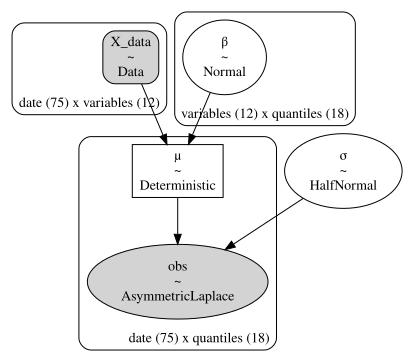

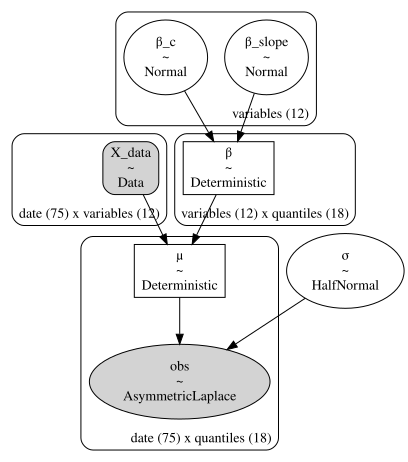

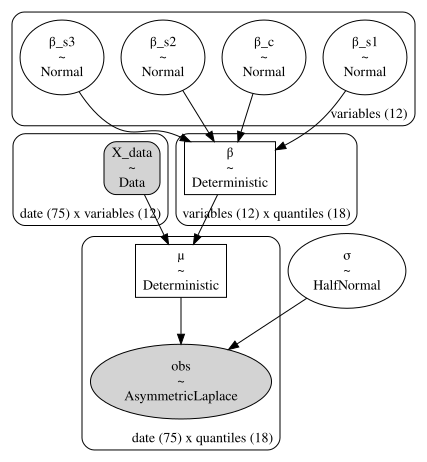

In [108]:
display(pm.model_to_graphviz(model=bqr_model_standard))
display(pm.model_to_graphviz(model=bqr_model_linear))
display(pm.model_to_graphviz(model=bqr_model_poly))

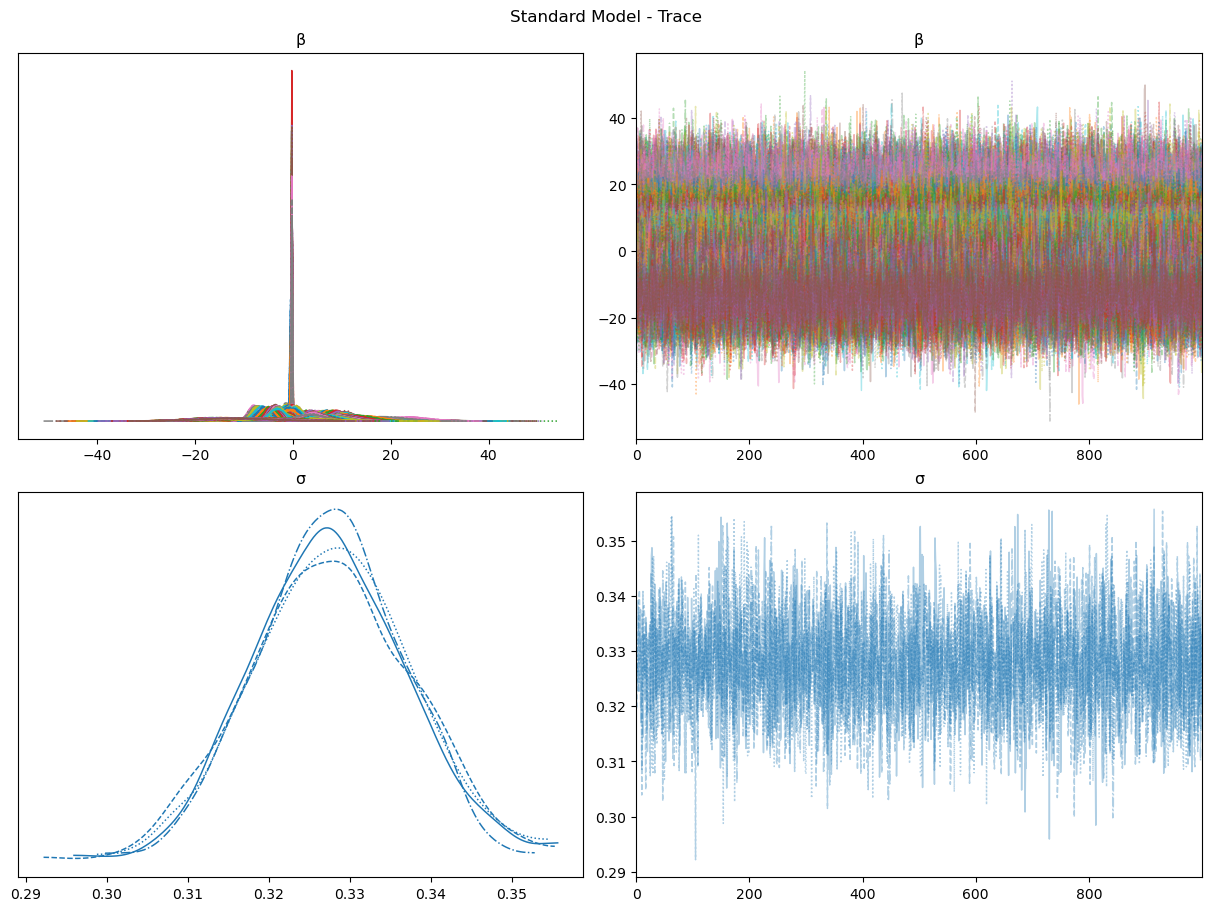

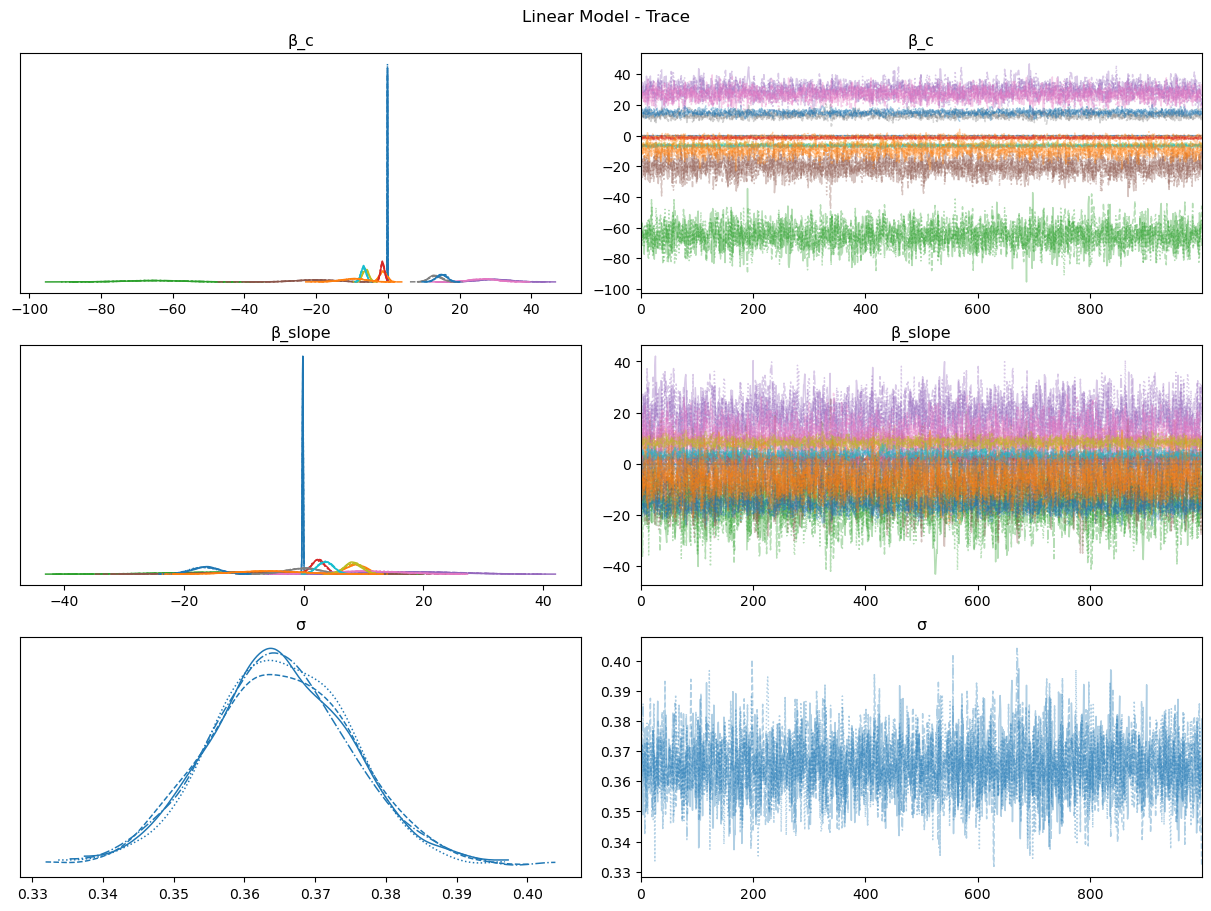

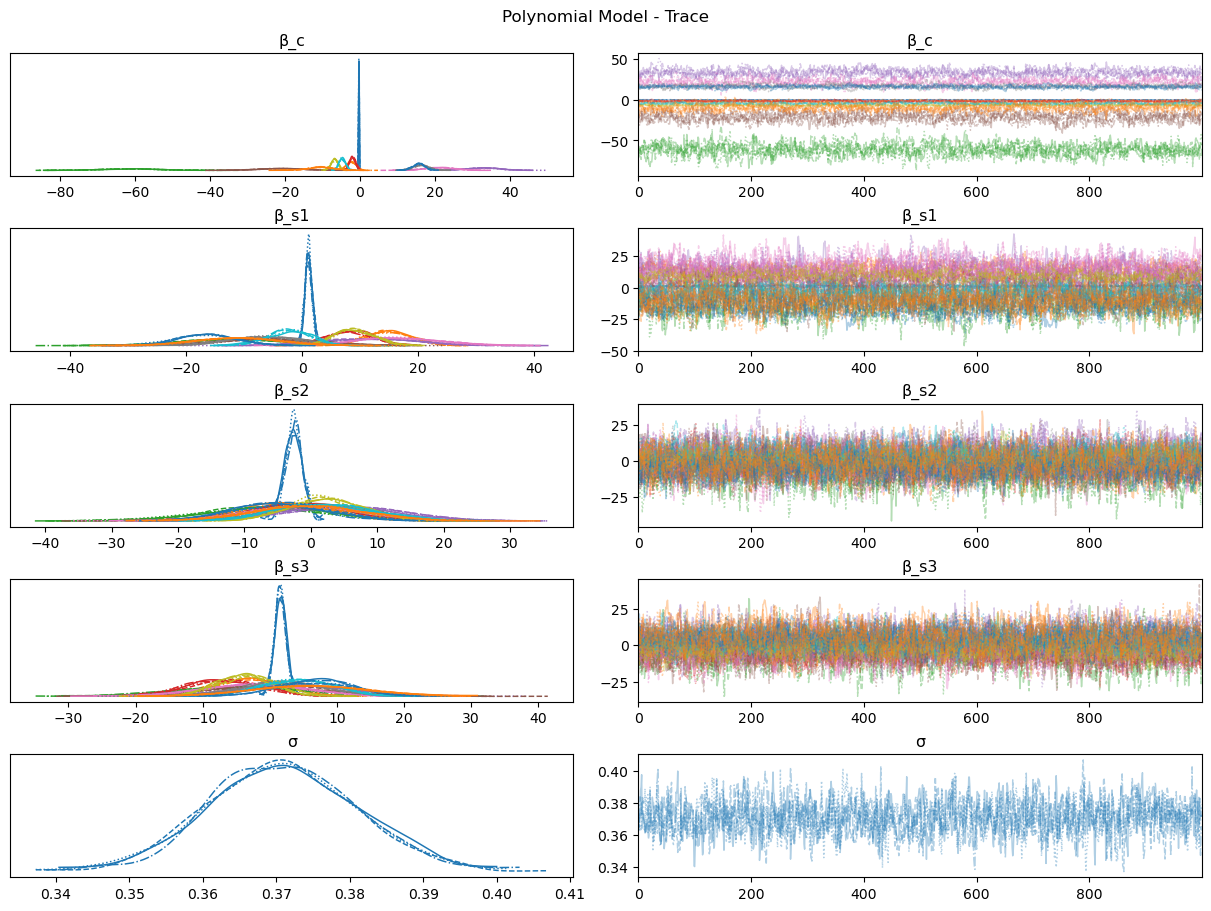

In [110]:
axes = az.plot_trace(
    data=trace_standard,
    var_names=['β', 'σ'],
    compact=True,
    backend_kwargs={
        "figsize": (12, 9),
        "layout": "constrained"
    },
)
fig = axes[0][0].get_figure()
fig.suptitle("Standard Model - Trace")
plt.show()

axes = az.plot_trace(
    data=trace_linear,
    var_names=['β_c', 'β_slope', 'σ'], 
    compact=True,
    backend_kwargs={
        "figsize": (12, 9),
        "layout": "constrained"
    },
)
fig = axes[0][0].get_figure()
fig.suptitle("Linear Model - Trace")
plt.show()

axes = az.plot_trace(
    data=trace_poly,
    var_names=['β_c', 'β_s1', 'β_s2', 'β_s3', 'σ'],
    compact=True,
    backend_kwargs={
        "figsize": (12, 9),
        "layout": "constrained"
    },
)
fig = axes[0][0].get_figure()
fig.suptitle("Polynomial Model - Trace")
plt.show()

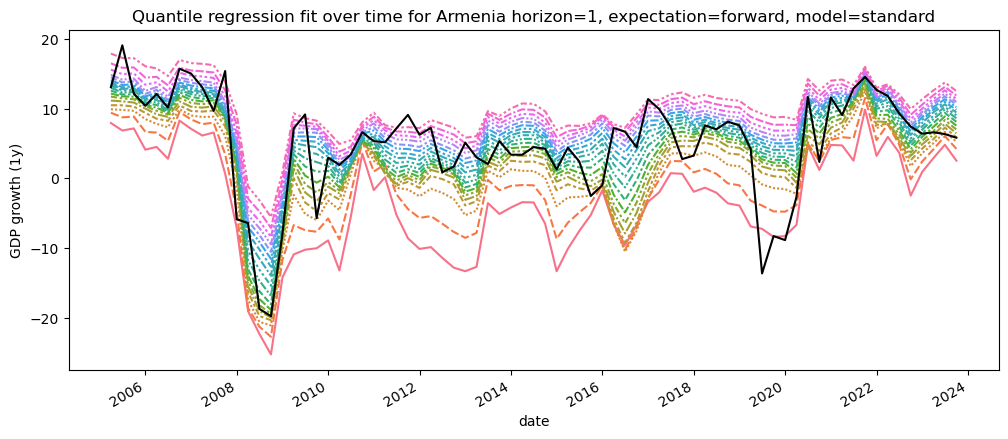

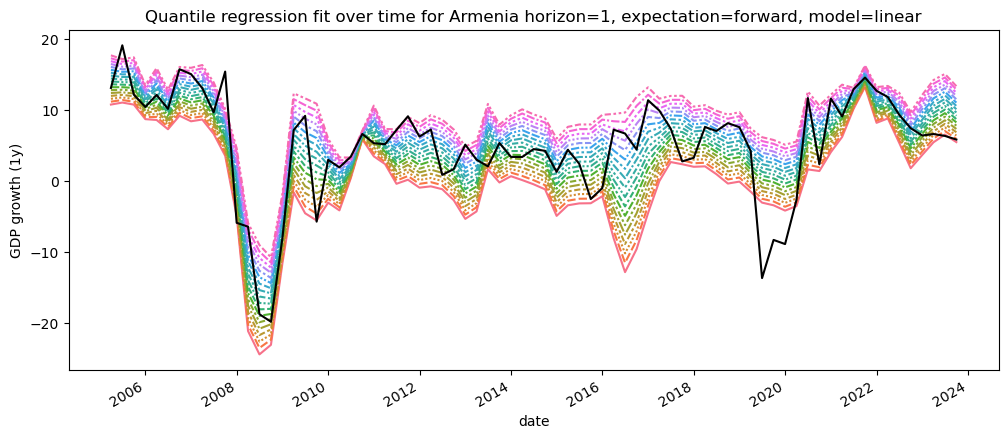

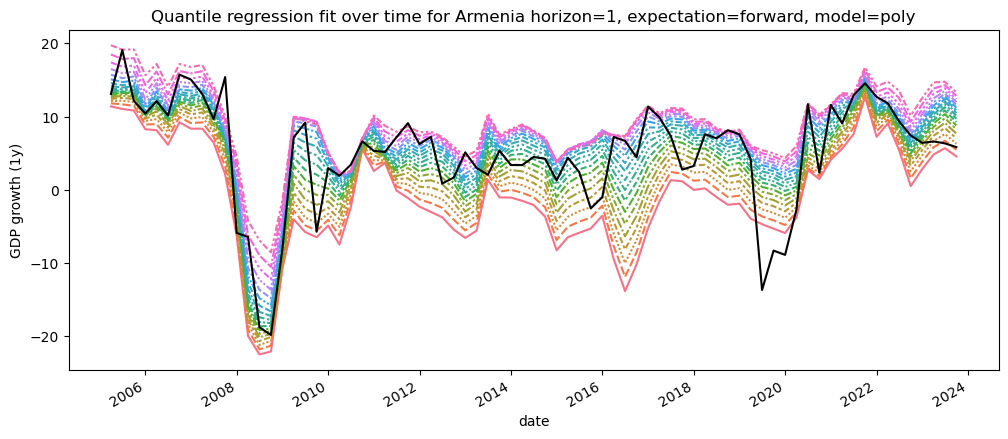

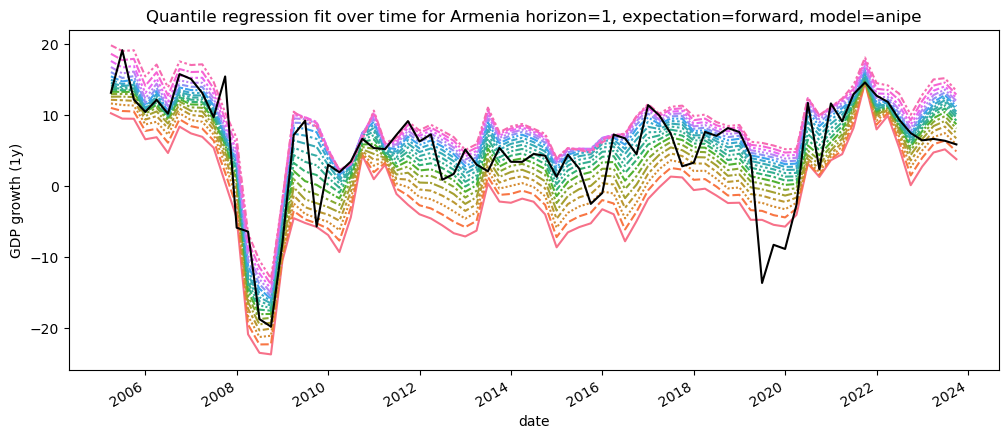

In [111]:
y_pred = arm_bqr_pred_standard['conditional_mean'].unstack('quantile')
actual = arm_bqr_pred_standard['actual'].unstack()[0.5]
fig, ax = plt.subplots(figsize=(12, 5))
g = sns.lineplot(data=y_pred, ax=ax)
actual.plot(color='black', ax=ax)
plt.title(f'Quantile regression fit over time for Armenia horizon={1}, expectation=forward, model=standard')
plt.ylabel(f'GDP growth ({int(1)}y)')
plt.legend([], [], frameon=False)
plt.show()

y_pred = arm_bqr_pred_linear['conditional_mean'].unstack('quantile')
actual = arm_bqr_pred_linear['actual'].unstack()[0.5]
fig, ax = plt.subplots(figsize=(12, 5))
g = sns.lineplot(data=y_pred, ax=ax)
actual.plot(color='black', ax=ax)
plt.title(f'Quantile regression fit over time for Armenia horizon={1}, expectation=forward, model=linear')
plt.ylabel(f'GDP growth ({int(1)}y)')
plt.legend([], [], frameon=False)
plt.show()

y_pred = arm_bqr_pred_poly['conditional_mean'].unstack('quantile')
actual = arm_bqr_pred_poly['actual'].unstack()[0.5]
fig, ax = plt.subplots(figsize=(12, 5))
g = sns.lineplot(data=y_pred, ax=ax)
actual.plot(color='black', ax=ax)
plt.title(f'Quantile regression fit over time for Armenia horizon={1}, expectation=forward, model=poly')
plt.ylabel(f'GDP growth ({int(1)}y)')
plt.legend([], [], frameon=False)
plt.show()

In [112]:
display(summary_standard)
display(summary_linear)
display(summary_poly)

,"GDP growth, q=0.1, h=4.0, e=forward","GDP growth, q=0.5, h=4.0, e=forward"
variable,,
β_autoregressive,-0.318**,-0.239***
,(0.2),(0.1)
β_const,1.533,5.917***
,(2.2),(2.1)
β_Financial Cycle Index,-10.855,-4.259
,(9.4),(9.6)
β_Financial Conditions Index,0.244,-0.177
,(1.6),(1.4)
β_Liquidity excess,13.816,15.832*


,"GDP growth, q=0.1, h=4.0, e=forward","GDP growth, q=0.5, h=4.0, e=forward"
variable,,
β_autoregressive,-0.110**,-0.174***
,(0.0),(0.0)
β_const,-0.414,3.036***
,(0.9),(0.8)
β_Financial Cycle Index,-66.721***,-72.306***
,(7.6),(8.1)
β_Financial Conditions Index,-1.205**,-0.252
,(0.5),(0.4)
β_Liquidity excess,31.404***,38.718***


,"GDP growth, q=0.1, h=4.0, e=forward","GDP growth, q=0.5, h=4.0, e=forward"
variable,,
β_autoregressive,-0.198***,-0.179***
,(0.1),(0.0)
β_const,-0.903,3.745***
,(1.0),(0.8)
β_Financial Cycle Index,-62.533***,-69.421***
,(7.2),(7.7)
β_Financial Conditions Index,-1.168**,1.021**
,(0.6),(0.5)
β_Liquidity excess,33.912***,40.124***


,"GDP growth, q=0.1, h=4.0, e=forward","GDP growth, q=0.5, h=4.0, e=forward"
variable,,
β_autoregressive,-0.237***,-0.194***
,(0.1),(0.0)
β_const,-0.445,3.822***
,(1.0),(0.8)
β_Financial Cycle Index,-69.397***,-74.065***
,(7.2),(7.5)
β_Financial Conditions Index,-0.951,0.453
,(0.6),(0.5)
β_Liquidity excess,31.929***,38.919***


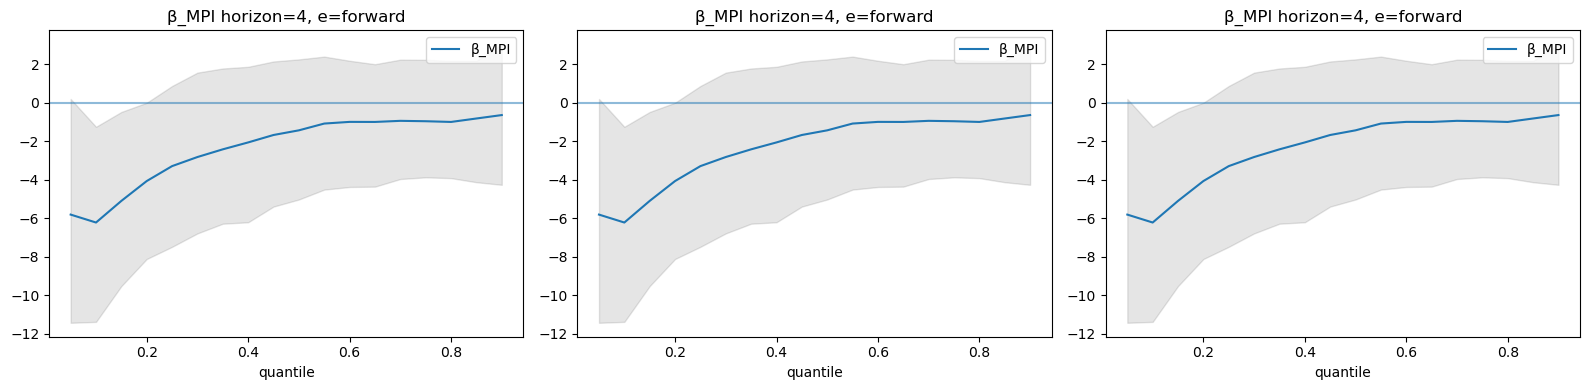

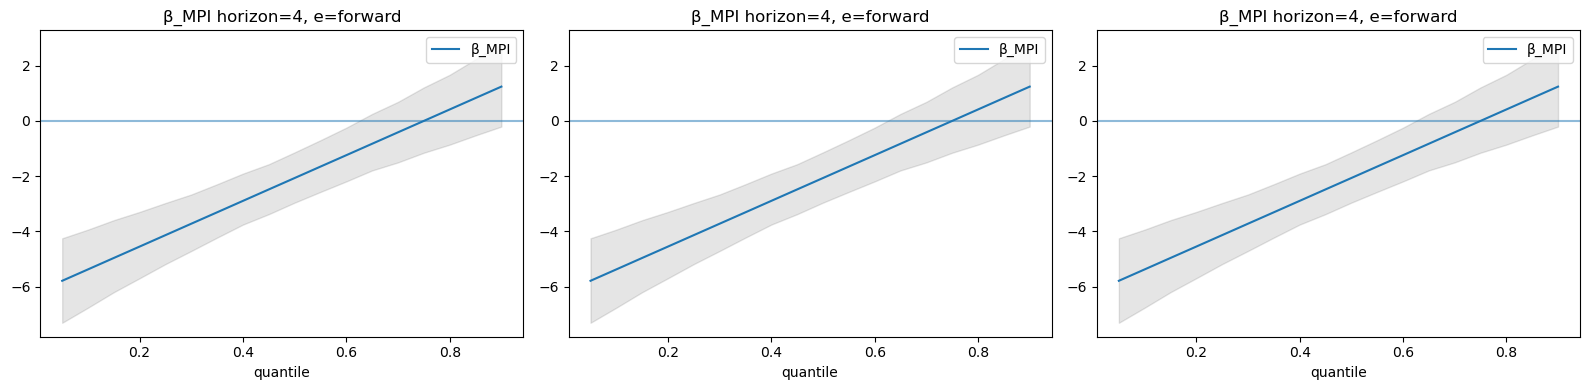

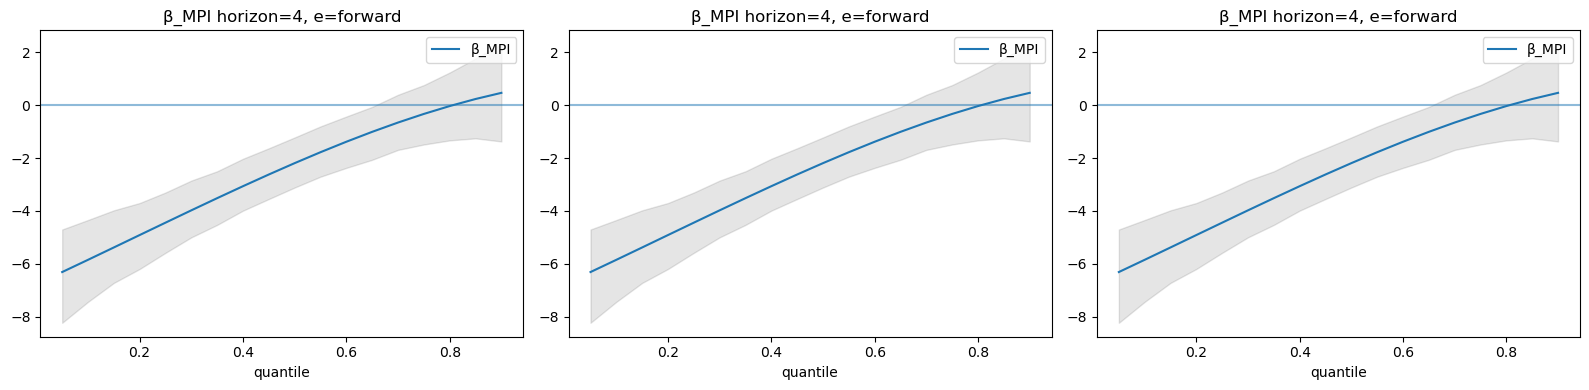

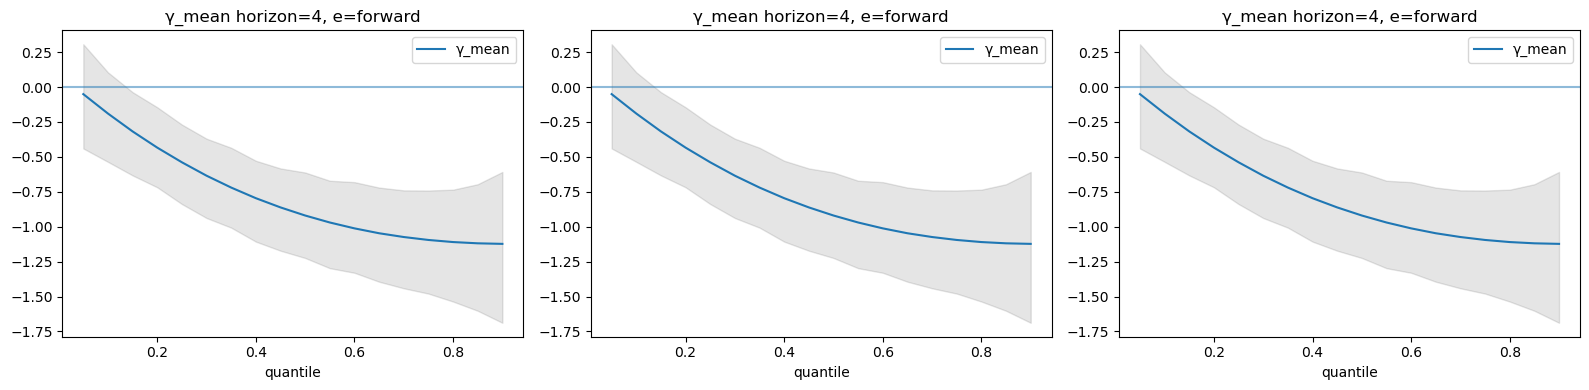

In [113]:
fig, axes = plt.subplots(1, len(horizons), figsize=(16, 4))
for h_index, h in enumerate(horizons):
    axes[h_index] = plot_qr_coeff(arm_bqcoef_standard, 'β_MPI', 'forward', 4, axes[h_index])
plt.tight_layout()
# plt.savefig('../results/arm_MPI_f_coeff_quantiles.png', bbox_inches='tight', dpi=300)
plt.show()

fig, axes = plt.subplots(1, len(horizons), figsize=(16, 4))
for h_index, h in enumerate(horizons):
    axes[h_index] = plot_qr_coeff(arm_bqcoef_linear, 'β_MPI', 'forward', 4, axes[h_index])
plt.tight_layout()
# plt.savefig('../results/arm_MPI_f_coeff_quantiles.png', bbox_inches='tight', dpi=300)
plt.show()

fig, axes = plt.subplots(1, len(horizons), figsize=(16, 4))
for h_index, h in enumerate(horizons):
    axes[h_index] = plot_qr_coeff(arm_bqcoef_poly, 'β_MPI', 'forward', 4, axes[h_index])
plt.tight_layout()
# plt.savefig('../results/arm_MPI_f_coeff_quantiles.png', bbox_inches='tight', dpi=300)
plt.show()

## with nonlinear interaction (policy) effects (NIE)

Note: the framework can also handle asymmetric tightening and loosening effects of macroprudential policy, but due to limited MPI data implementing this is not feasible.

In [58]:
def T_sigmoid(x, smoothness, threshold):
    """A centered sigmoid function."""
    center = 1 / (1 + pt.exp(smoothness*threshold))
    sig = 1 / (1 + pt.exp(-smoothness*(pt.abs(x) - threshold)))
    return sig - center

In [59]:
# model definition and fitting
γ_offsets = np.array([1, 0, 0, 5, 2, 0, 1])
with pm.Model(coords=coords_other) as bqr_model_nie:
    # data containers
    X_data = pm.Data(name="X_other", value=X_other, dims=("date", "variables"))
    mpi = pm.Data(name="MPI", value=X_mpi.values, dims="date")
    fcyi_norm = pm.Data(name="N(FCyI)", value=X_fcyi_norm.values, dims="date")
    fci_norm = pm.Data(name="N(FCI)", value=X_fci_norm.values, dims="date")
    car_excess = pm.Data(name="CaR excess", value=X_car_excess.values, dims="date")

    # hyperparameter
    a_ref = 1
    λ_smoothness = pm.HalfNormal("λ_smoothness", 4)

    # policy coefficients
    γ_coeffs_raw = pm.HalfNormal("γ_coeffs_raw", sigma=0.5, dims=("gamma_terms",))
    γ_coeffs = pm.Deterministic("γ_coeffs", γ_coeffs_raw + γ_offsets, dims=("gamma_terms",))
    γ_const = γ_coeffs[0] + γ_coeffs[1]*fcyi_norm + γ_coeffs[2]*fci_norm
    γ_const = pm.Deterministic("γ_const", γ_const, dims=("date",))
    γ_slope = -(γ_coeffs[3] + (γ_coeffs[1] / 0.5)*fcyi_norm + (γ_coeffs[2] / 0.1)*fci_norm)
    γ_slope = pm.Deterministic("γ_slope", γ_slope, dims=("date",))
    γ_poly = (γ_coeffs[4])*quantiles**2 - γ_coeffs[5]*quantiles**3
    γ_poly = pm.Deterministic("γ_poly", γ_poly, dims=("quantiles",))

    # policy effects
    γ = (γ_coeffs[6]*(1 - car_excess))[:, None]*(γ_const[:, None] + γ_slope[:, None]*quantiles + γ_poly)
    γ = pm.Deterministic("γ", γ, dims=("date", "quantiles"))

    # nonlinear policy impact function
    f_γ = pm.Deterministic("f(γ, MPI)", 2*γ*T_sigmoid(mpi, λ_smoothness, a_ref)[:, None], dims=("date", "quantiles"))

    # exog parameters
    β_coeffs = pm.Normal("β_coeffs", 0, 10, dims=("variables", "poly_terms"))
    β = pm.Deterministic("β", β_coeffs @ quantile_powers, dims=("variables", "quantiles"))

    # estimation
    σ = pm.HalfNormal("σ", 10)
    μ_mpi = pm.Deterministic('μ_mpi', mpi[:, None] * f_γ, dims=("date", "quantiles"))  # outer product
    μ_other = pm.Deterministic('μ_other', X_data @ β, dims=("date", "quantiles"))
    μ = pm.Deterministic('μ', μ_other + μ_mpi, dims=("date", "quantiles"))

    # likelihood function
    obs = pm.AsymmetricLaplace("obs", mu=μ, b=σ, q=quantiles, observed=y_stack, dims=("date", "quantiles"))

    # # constraints
    # qt_index = pt.where(quantiles == 0.2)[0][0]
    # γ_penalty_t = pm.Deterministic('γ_penalty_t', pm.math.mean(γ[:, :qt_index+1] < 0))
    # γ_penalty_m = pm.Deterministic('γ_penalty_m', pm.math.mean(γ[:, qt_index+1:] > 0))
    # pm.Potential("γ_penalty", -15*(γ_penalty_t+γ_penalty_m))

    # sampling
    trace_nie = pm.sample(nuts_sampler="pymc", tune=1_000, draws=1_000, chains=4,
                          idata_kwargs={"log_likelihood": True},
                          nuts_sampler_kwargs={"max_treedepth": 10, "target_accept": 0.95})  # Default is 0.8

/Users/victoryerz/anaconda3/lib/python3.11/site-packages/pytensor/tensor/math.py:893: FutureWarning: sgn is deprecated and will stop working in the future, use sign instead.
  warnings.warn(
/Users/victoryerz/anaconda3/lib/python3.11/site-packages/pytensor/tensor/math.py:893: FutureWarning: sgn is deprecated and will stop working in the future, use sign instead.
  warnings.warn(
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
/Users/victoryerz/anaconda3/lib/python3.11/site-packages/pytensor/tensor/math.py:893: FutureWarning: sgn is deprecated and will stop working in the future, use sign instead.
  warnings.warn(
/Users/victoryerz/anaconda3/lib/python3.11/site-packages/pytensor/tensor/math.py:893: FutureWarning: sgn is deprecated and will stop working in the future, use sign instead.
  warnings.warn(
/Users/victoryerz/anaconda3/lib/python3.11/site-packages/pytensor/tensor/math.py:893: FutureWarning: sgn is deprecated and will stop working in the future, use 

Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 616 seconds.
/Users/victoryerz/anaconda3/lib/python3.11/site-packages/pytensor/tensor/math.py:893: FutureWarning: sgn is deprecated and will stop working in the future, use sign instead.
  warnings.warn(


## main model results

In [60]:
trace_nie.posterior["γ_const_mean"] = trace_nie.posterior["γ_const"].mean(dim="date")
trace_nie.posterior["γ_slope_mean"] = trace_nie.posterior["γ_slope"].mean(dim="date")
trace_nie.posterior["γ_mean"] = trace_nie.posterior["γ"].mean(dim="date")
arm_bqcoef_nie, arm_bqr_pred_nie = bqr_results(trace_nie, var_names=['β', 'γ_coeffs', 'γ_const_mean', 'γ_slope_mean',
                                                                     'γ_mean', 'λ_smoothness', 'σ'])

# added more cols
arm_bqcoef_nie['expectation'] = 'forward'
arm_bqcoef_nie['horizon'] = 4.0
arm_bqcoef_nie.set_index(['expectation', 'horizon'], append=True, inplace=True)
arm_bqcoef_nie = arm_bqcoef_nie.reorder_levels(['expectation', 'horizon', 'variable', 'quantile'])

# generating a summary table
summary_nie = summary_with_stars(arm_bqcoef_nie, q=[0.1, 0.5], prefix='GDP growth, ')

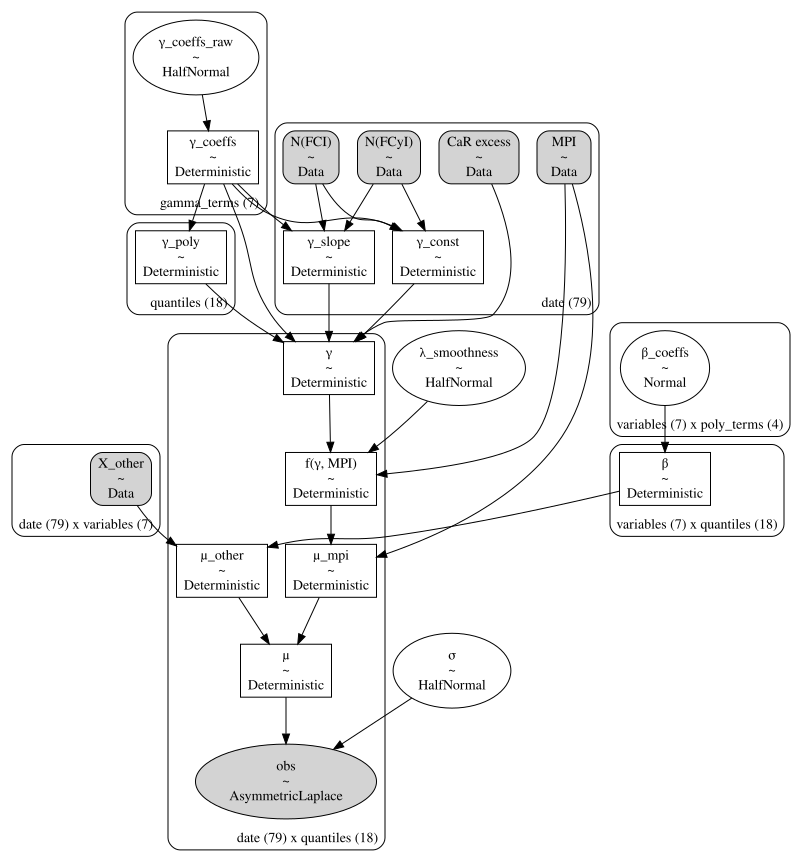

In [61]:
display(pm.model_to_graphviz(model=bqr_model_nie))

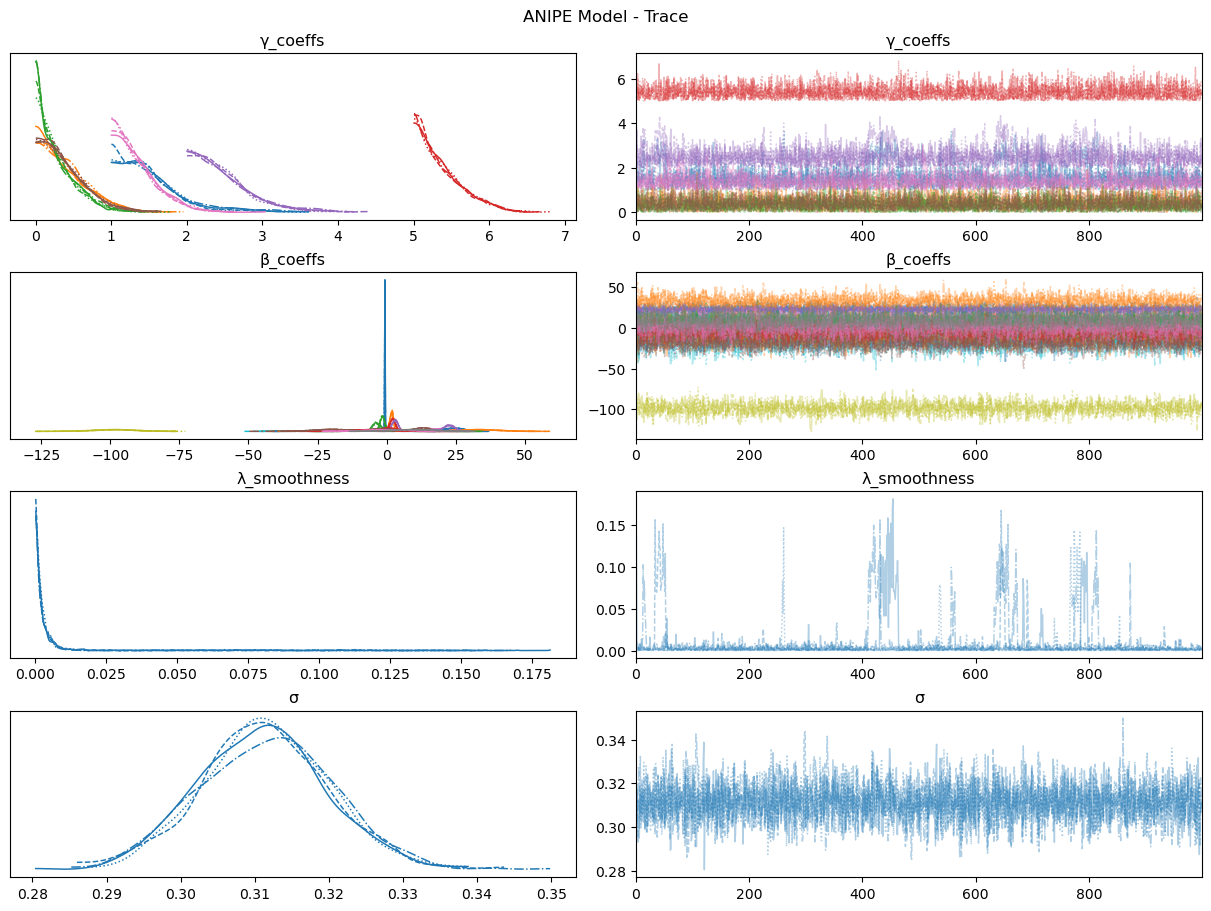

In [62]:
axes = az.plot_trace(
    data=trace_nie,
    var_names=['γ_coeffs', 'β_coeffs', 'λ_smoothness', 'σ'],
    compact=True,
    backend_kwargs={
        "figsize": (12, 9),
        "layout": "constrained"
    },
)
fig = axes[0][0].get_figure()
fig.suptitle("ANIPE Model - Trace")
plt.show()

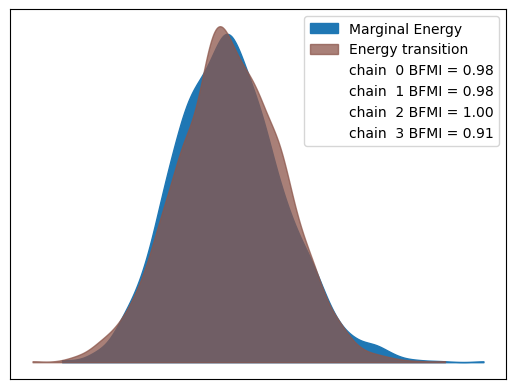

In [63]:
az.plot_energy(trace_nie)
plt.show()

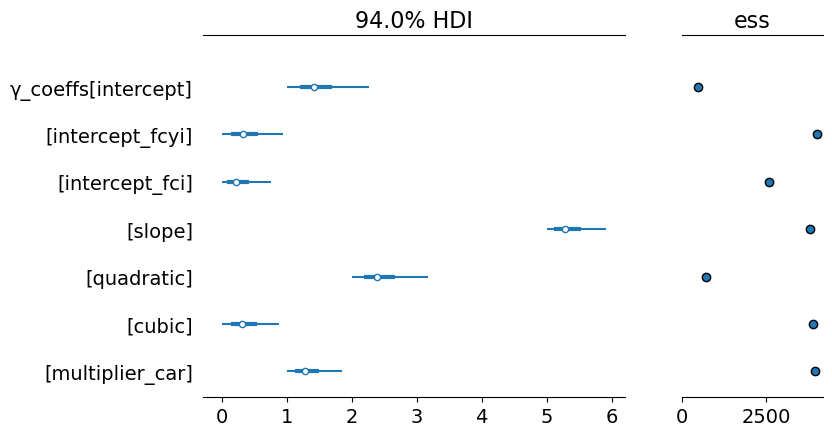

In [64]:
az.plot_forest(trace_nie, var_names=["γ_coeffs"], combined=True, ess=True)  # Exclude 'obs' for clarity
plt.show()

In [65]:
# model_dict = {'NIE model': trace_nie}
# display(az.compare(compare_dict=model_dict, ic="loo", method="stacking", scale="log"))

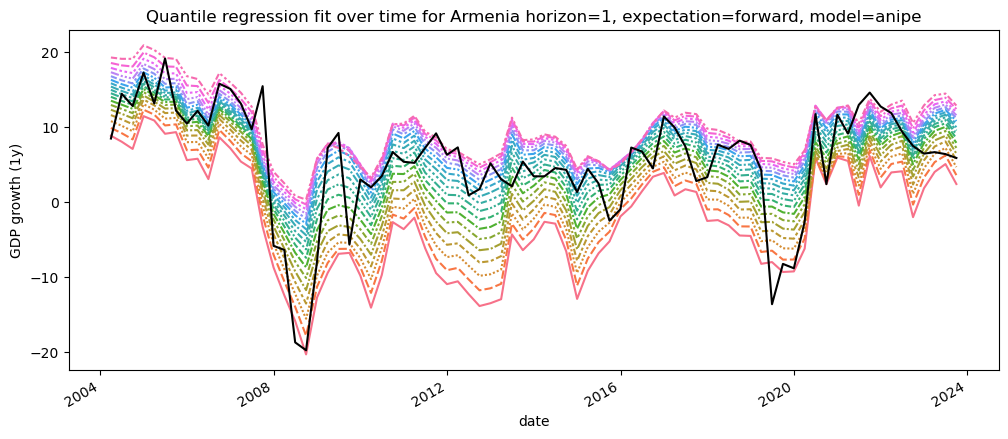

In [66]:
y_pred = arm_bqr_pred_nie['conditional_mean'].unstack('quantile')
actual = arm_bqr_pred_nie['actual'].unstack()[0.5]
fig, ax = plt.subplots(figsize=(12, 5))
g = sns.lineplot(data=y_pred, ax=ax)
actual.plot(color='black', ax=ax)
plt.title(f'Quantile regression fit over time for Armenia horizon={1}, expectation=forward, model=anipe')
plt.ylabel(f'GDP growth ({int(1)}y)')
plt.legend([], [], frameon=False)
plt.show()

Sampling: [obs, β_coeffs, γ_coeffs_raw, λ_smoothness, σ]


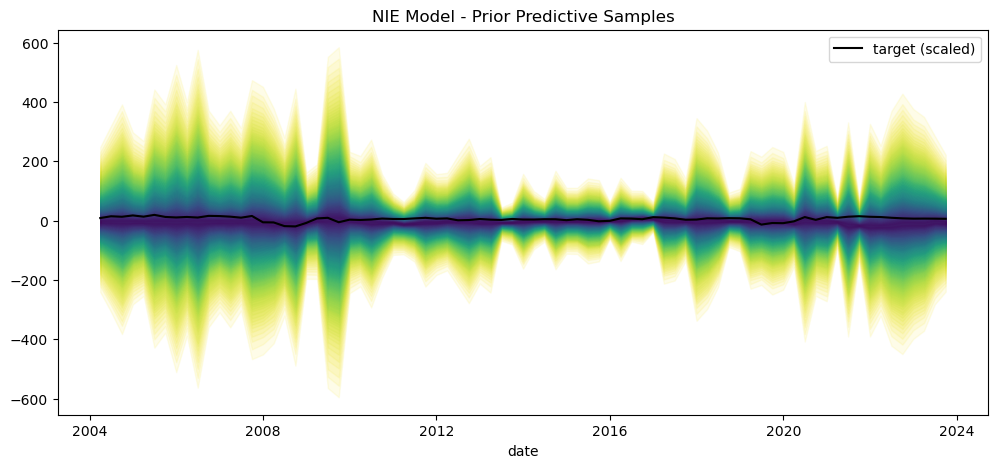

In [67]:
nie_prior_predictive = pm.sample_prior_predictive(model=bqr_model_nie)

# useful way to color the distribution
palette = "viridis_r"
cmap = plt.get_cmap(palette)
percs = np.linspace(51, 99, 100)
colors = (percs - np.min(percs)) / (np.max(percs) - np.min(percs))

fig, ax = plt.subplots(figsize=(12, 5))
for i, p in enumerate(percs[::-1]):
    upper = np.percentile(nie_prior_predictive.prior_predictive["obs"], p, axis=(0, 1, 3))
    lower = np.percentile(
        nie_prior_predictive.prior_predictive["obs"], 100 - p, axis=(0, 1, 3)
    )
    color_val = colors[i]
    ax.fill_between(
        x=date,
        y1=upper.flatten(),
        y2=lower.flatten(),
        color=cmap(color_val),
        alpha=0.1,
    )
sns.lineplot(x=date, y=actual.values, color="black", label="target (scaled)", ax=ax)
ax.legend()
ax.set(title="NIE Model - Prior Predictive Samples")
plt.show()

In [68]:
display(summary_nie)
display(arm_bqcoef_nie[arm_bqcoef_nie.index.get_level_values('quantile').isin([0])])

,"GDP growth, q=0.1, h=4.0, e=forward","GDP growth, q=0.5, h=4.0, e=forward"
variable,,
β_autoregressive,-0.440***,-0.287***
,(0.1),(0.0)
β_const,4.350***,8.554***
,(0.9),(0.7)
β_Financial Cycle Index,-100.481***,-110.458***
,(7.1),(7.6)
β_Financial Conditions Index,-1.464***,-1.974***
,(0.6),(0.5)
β_Liquidity excess,20.768***,22.532***


coeff     se   lower  \
expectation horizon variable                quantile                         
forward     4.0     γ_coeffs_intercept      0.0       1.510  0.421   1.000   
                    γ_coeffs_intercept_fcyi 0.0       0.391  0.300   0.000   
                    γ_coeffs_intercept_fci  0.0       0.286  0.258   0.000   
                    γ_coeffs_slope          0.0       5.356  0.294   5.000   
                    γ_coeffs_quadratic      0.0       2.470  0.380   2.000   
                    γ_coeffs_cubic          0.0       0.374  0.286   0.001   
                    γ_coeffs_multiplier_car 0.0       1.343  0.277   1.000   
                    γ_const_mean            0.0       1.829  0.429   1.092   
                    γ_slope_mean            0.0      -7.355  1.604 -10.506   
                    λ_smoothness            0.0       0.006  0.019   0.000   
                    σ                       0.0       0.311  0.009   0.295   

                                                      upper  ess_bulk  \
expectation horizon variable                quantile                    
forward     4.0     γ_coeffs_intercept      0.0       2.370     708.0   
                    γ_coeffs_intercept_fcyi 0.0       0.976    2738.0   
                    γ_coeffs_intercept_fci  0.0       0.799    1370.0   
                    γ_coeffs_slope          0.0       5.944    2215.0   
                    γ_coeffs_quadratic      0.0       3.223     929.0   
                    γ_coeffs_cubic          0.0       0.927    2379.0   
                    γ_coeffs_multiplier_car 0.0       1.888    2519.0   
                    γ_const_mean            0.0       2.675     945.0   
                    γ_slope_mean            0.0      -5.097    1171.0   
                    λ_smoothness            0.0       0.022     780.0   
                    σ                       0.0       0.329    4786.0   

                                                      ess_tail  r_hat  pval  \
expectation horizon variable                quantile                          
forward     4.0     γ_coeffs_intercept      0.0          335.0   1.01   0.0   
                    γ_coeffs_intercept_fcyi 0.0         1609.0   1.00   0.0   
                    γ_coeffs_intercept_fci  0.0         1136.0   1.00   0.0   
                    γ_coeffs_slope          0.0         1398.0   1.00   0.0   
                    γ_coeffs_quadratic      0.0          588.0   1.00   0.0   
                    γ_coeffs_cubic          0.0         1512.0   1.00   0.0   
                    γ_coeffs_multiplier_car 0.0         1573.0   1.00   0.0   
                    γ_const_mean            0.0          582.0   1.00   0.0   
                    γ_slope_mean            0.0          821.0   1.00   0.0   
                    λ_smoothness            0.0          235.0   1.01   0.0   
                    σ                       0.0         2857.0   1.00   0.0   

                                                      pseudoR2  
expectation horizon variable                quantile            
forward     4.0     γ_coeffs_intercept      0.0            NaN  
                    γ_coeffs_intercept_fcyi 0.0            NaN  
                    γ_coeffs_intercept_fci  0.0            NaN  
                    γ_coeffs_slope          0.0            NaN  
                    γ_coeffs_quadratic      0.0            NaN  
                    γ_coeffs_cubic          0.0            NaN  
                    γ_coeffs_multiplier_car 0.0            NaN  
                    γ_const_mean            0.0            NaN  
                    γ_slope_mean            0.0            NaN  
                    λ_smoothness            0.0            NaN  
                    σ                       0.0            NaN

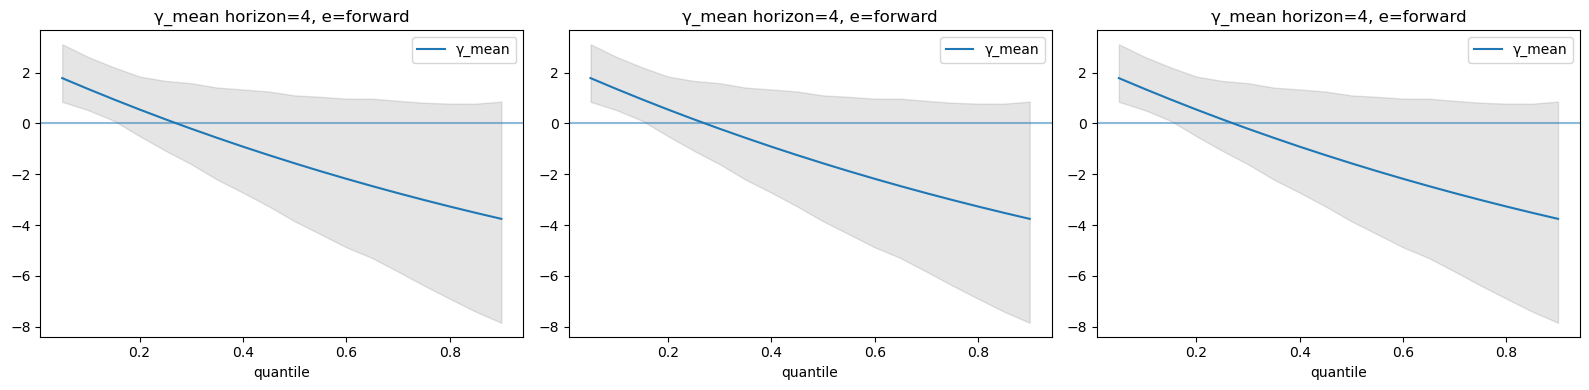

In [69]:
fig, axes = plt.subplots(1, len(horizons), figsize=(16, 4))
for h_index, h in enumerate(horizons):
    axes[h_index] = plot_qr_coeff(arm_bqcoef_nie, 'γ_mean', 'forward', 4, axes[h_index])
plt.tight_layout()
# plt.savefig('../results/arm_MPI_f_coeff_quantiles.png', bbox_inches='tight', dpi=300)
plt.show()

In [70]:
display(arm_bqcoef_nie[arm_bqcoef_nie['r_hat'] > 1.05])

,,,,coeff,se,lower,upper,ess_bulk,ess_tail,r_hat,pval,pseudoR2
expectation,horizon,variable,quantile,,,,,,,,,


In [71]:
print('γ_coeffs:', ','.join(az.summary(trace_nie, var_names=['γ_coeffs'])['mean'].values.astype(str)))

γ_coeffs: 1.51,0.391,0.286,5.356,2.47,0.374,1.343
